<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/CIA-3/CIA_3_2015_Gorkha_Earthquake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
                              confusion_matrix, precision_score, recall_score)
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
values = pd.read_csv('/content/drive/MyDrive/ML Datasets/CIA3/train_values.csv')
labels = pd.read_csv('/content/drive/MyDrive/ML Datasets/CIA3/train_labels.csv')
df = values.merge(labels, on='building_id')
print(df.shape)          # expect (260601, 40)
print(df['damage_grade'].value_counts())  # check class imbalance

(260601, 40)
damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64


## EDA

In [8]:
# 1. Missing values
print("\n--- 1. Missing Values ---")
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})
print(missing_info[missing_info['Missing Count'] > 0])
flagged_columns = missing_info[missing_info['Missing Percentage'] > 5].index.tolist()
if flagged_columns:
    print(f"Columns with more than 5% missing values: {flagged_columns}")
else:
    print("No columns with more than 5% missing values.")

# 2. Duplicate rows
print("\n--- 2. Duplicate Rows ---")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")
if duplicate_rows > 0:
    print("Sample of duplicate rows:")
    display(df[df.duplicated(keep=False)].head())

# 3. Data types per column
print("\n--- 3. Data Types ---")
print(df.info())
print("\nPotential issues: 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id' are numeric but represent geographical categories and could potentially be treated as categorical. Review `has_superstructure_` columns which are int64 but are binary/boolean.")




--- 1. Missing Values ---
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
No columns with more than 5% missing values.

--- 2. Duplicate Rows ---
Number of duplicate rows: 0

--- 3. Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       26

In [9]:
# 4. Class distribution of damage_grade
print("\n--- 4. Class Distribution of damage_grade ---")
damage_counts = df['damage_grade'].value_counts()
damage_percentages = df['damage_grade'].value_counts(normalize=True) * 100
print("Counts:")
print(damage_counts)
print("\nPercentages:")
print(damage_percentages)

max_percentage = damage_percentages.max()
min_percentage = damage_percentages.min()
if max_percentage > 2 * min_percentage:
    print("\nConclusion: The 'damage_grade' class distribution is imbalanced.")
else:
    print("\nConclusion: The 'damage_grade' class distribution is relatively balanced.")





--- 4. Class Distribution of damage_grade ---
Counts:
damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

Percentages:
damage_grade
2    56.891186
3    33.468022
1     9.640792
Name: proportion, dtype: float64

Conclusion: The 'damage_grade' class distribution is imbalanced.


In [10]:
# 5. Basic outlier check on numeric columns
print("\n--- 5. Outlier Check on Numeric Columns ---")
numeric_cols = ['age', 'area_percentage', 'height_percentage', 'count_floors_pre_eq']
for col in numeric_cols:
    if col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        percentile_99 = df[col].quantile(0.99)
        print(f"\nColumn: {col}")
        print(f"  Min: {min_val}")
        print(f"  Max: {max_val}")
        print(f"  99th Percentile: {percentile_99}")
    else:
        print(f"Column '{col}' not found in DataFrame.")




--- 5. Outlier Check on Numeric Columns ---

Column: age
  Min: 0
  Max: 995
  99th Percentile: 100.0

Column: area_percentage
  Min: 1
  Max: 100
  99th Percentile: 23.0

Column: height_percentage
  Min: 2
  Max: 32
  99th Percentile: 11.0

Column: count_floors_pre_eq
  Min: 1
  Max: 9
  99th Percentile: 4.0


In [11]:
# 6. Cardinality check on categorical/geo columns
print("\n--- 6. Cardinality Check on Categorical/Geo Columns ---")
geo_cols = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']
type_cols = [col for col in df.columns if '_type' in col]
cardinality_cols = geo_cols + type_cols

for col in cardinality_cols:
    if col in df.columns:
        unique_count = df[col].nunique()
        print(f"Column '{col}': {unique_count} unique values")
    else:
        print(f"Column '{col}' not found in DataFrame.")


--- 6. Cardinality Check on Categorical/Geo Columns ---
Column 'geo_level_1_id': 31 unique values
Column 'geo_level_2_id': 1414 unique values
Column 'geo_level_3_id': 11595 unique values
Column 'foundation_type': 5 unique values
Column 'roof_type': 3 unique values
Column 'ground_floor_type': 5 unique values
Column 'other_floor_type': 4 unique values


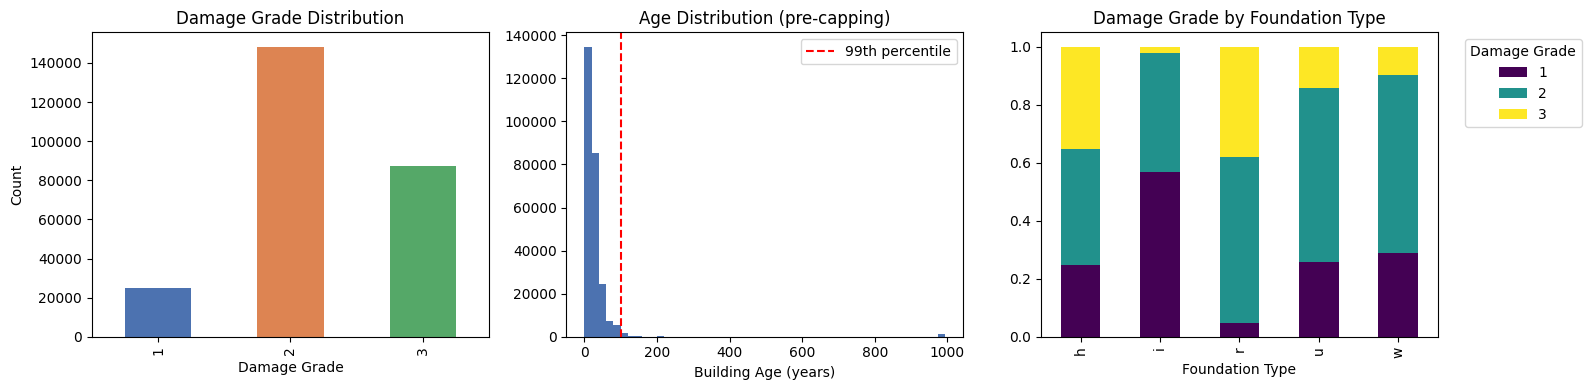

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class distribution
df['damage_grade'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Damage Grade Distribution')
axes[0].set_xlabel('Damage Grade')
axes[0].set_ylabel('Count')

# 2. Age distribution — shows why capping is needed
axes[1].hist(df['age'], bins=50, color='#4C72B0')
axes[1].axvline(df['age'].quantile(0.99), color='red', linestyle='--', label='99th percentile')
axes[1].set_title('Age Distribution (pre-capping)')
axes[1].set_xlabel('Building Age (years)')
axes[1].legend()

# 3. Damage grade by foundation type
pd.crosstab(df['foundation_type'], df['damage_grade'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[2], colormap='viridis')
axes[2].set_title('Damage Grade by Foundation Type')
axes[2].set_xlabel('Foundation Type')
axes[2].legend(title='Damage Grade', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## EDA Summary — Key Takeaways

- **Data quality is clean**: no missing values and no duplicate rows across 260,601 records — minimal wrangling overhead, effort redirected to feature engineering and encoding.
- **Target is imbalanced**: damage_grade skews toward grade 2 (56.9%) and grade 3 (33.5%), with grade 1 (low damage) underrepresented at 9.6%. Addressed via `class_weight='balanced'` rather than oversampling, given dataset size.
- **`age` contains implausible outliers**: max value of 995 years against a 99th percentile of 100 indicates data-entry artifacts, not real building ages. Capped at the 99th percentile; no other numeric column showed comparable distortion.
- **Geo columns are high-cardinality**: `geo_level_3_id` (11,595 unique values) and `geo_level_2_id` (1,414 unique values) risk leakage and overfitting if encoded directly — `geo_level_3_id` dropped, both `geo_level_1_id`/`geo_level_2_id` frequency-encoded instead of one-hot encoded.
- **Structural features show real signal**: damage grade varies visibly by foundation type, supporting the choice to engineer domain features (e.g., superstructure count, height-to-floor ratio) rather than relying on raw categoricals alone.

## Dropping columns

In [12]:
# --- Step 4: Drop identifiers / high-cardinality leakage-risk columns ---
df = df.drop(columns=["building_id", "geo_level_3_id"])

# Frequency-encode coarser geo columns (retain regional signal, avoid one-hot blow-up)
for col in ["geo_level_1_id", "geo_level_2_id"]:
    freq = df[col].value_counts(normalize=True)
    df[col + "_freq"] = df[col].map(freq)
df = df.drop(columns=["geo_level_1_id", "geo_level_2_id"])

print(df.shape)  # expect (260601, 38)
df.head()

(260601, 38)


,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,geo_level_1_id_freq,geo_level_2_id_freq
0,2,30,6,5,t,r,n,f,q,t,...,0,0,0,0,0,0,0,3,0.093557,0.001036
1,2,10,8,7,o,r,n,x,q,s,...,0,0,0,0,0,0,0,2,0.073215,0.000764
2,2,10,5,5,t,r,n,f,x,t,...,0,0,0,0,0,0,0,3,0.057133,0.006754
3,2,10,6,5,t,r,n,f,x,s,...,0,0,0,0,0,0,0,2,0.023991,0.000787
4,3,30,8,9,t,r,n,f,x,s,...,0,0,0,0,0,0,0,3,0.031542,0.003983


### Why should we drop `building_id` and 1geo_level_3_id`?

- **`building_id`**: A unique random identifier with no predictive relationship to damage outcome. Including it would add noise and risk the model spuriously memorizing per-building identity rather than learning generalizable structural patterns.

- **`geo_level_3_id`**: Highest-resolution geographic code with 11,595 unique values. At this granularity, the feature functions almost as a proxy for individual village/neighborhood identity rather than a generalizable regional signal. Encoding it directly (one-hot or label encoding) would:
  - Cause severe dimensionality blow-up (thousands of sparse columns)
  - Risk leakage — the model could learn "which specific location was hit hardest" rather than "which structural characteristics predict damage," undermining generalizability to buildings/regions outside this dataset
  - Overfit to region-specific quirks rather than transferable engineering/construction risk factors

  `geo_level_1_id` and `geo_level_2_id` are retained (frequency-encoded) as they capture coarser regional variation — a reasonable proxy for shared seismic intensity or regional construction norms — without the extreme cardinality and leakage risk of level 3.

## Feature engineering

In [15]:

df["age_area_ratio"] = df["age"] / (df["area_percentage"] + 1)
df["height_floor_ratio"] = df["height_percentage"] / (df["count_floors_pre_eq"] + 1)
df["superstructure_count"] = df.filter(like="has_superstructure_").sum(axis=1)

print(df.shape)  # expect (260601, 41)
df[["age_area_ratio", "height_floor_ratio", "superstructure_count"]].describe()

(260601, 41)


,age_area_ratio,height_floor_ratio,superstructure_count
count,260601.000000,260601.000000,260601.000000
mean,3.461789,1.719426,1.460002
std,10.073257,0.389626,0.776945
min,0.000000,0.250000,1.000000
25%,0.909091,1.500000,1.000000
50%,2.000000,1.666667,1.000000
75%,3.750000,2.000000,2.000000
max,331.666667,16.000000,8.000000




- **`age_area_ratio`** (age ÷ area_percentage): Captures whether older buildings occupy disproportionately small footprints — a proxy for outdated, cramped construction that may correlate with structural vulnerability.
- **`height_floor_ratio`** (height_percentage ÷ count_floors_pre_eq): Flags buildings that are unusually tall relative to their floor count — potentially indicating tall single-story structures or inconsistent floor-height construction, both plausible earthquake-risk factors.
- **`superstructure_count`**: Sum of all `has_superstructure_*` binary flags. A building using multiple superstructure materials may indicate ad-hoc/retrofit construction rather than a single engineered material choice — worth testing as a risk signal.

These are engineered from structural/construction attributes already in the dataset (not external data), keeping the pipeline reproducible and leakage-safe — no information from the target or post-earthquake outcome is used.

### Outlier Handling — `age`

The EDA audit showed `age` has a max of 995 against a 99th percentile of 100 — a clear data-entry artifact rather than a real building age. Capping at the 99th percentile removes this distortion while preserving the natural spread of the remaining 99% of values. No other numeric column (`area_percentage`, `height_percentage`, `count_floors_pre_eq`) showed comparably implausible extremes, so only `age` requires this treatment.

In [16]:
age_cap = df["age"].quantile(0.99)
df["age"] = df["age"].clip(upper=age_cap)

print(f"Age capped at: {age_cap}")
df["age"].describe()

Age capped at: 100.0


,age
count,260601.000000
mean,21.656229
std,19.800349
min,0.000000
25%,10.000000
50%,15.000000
75%,30.000000
max,100.000000


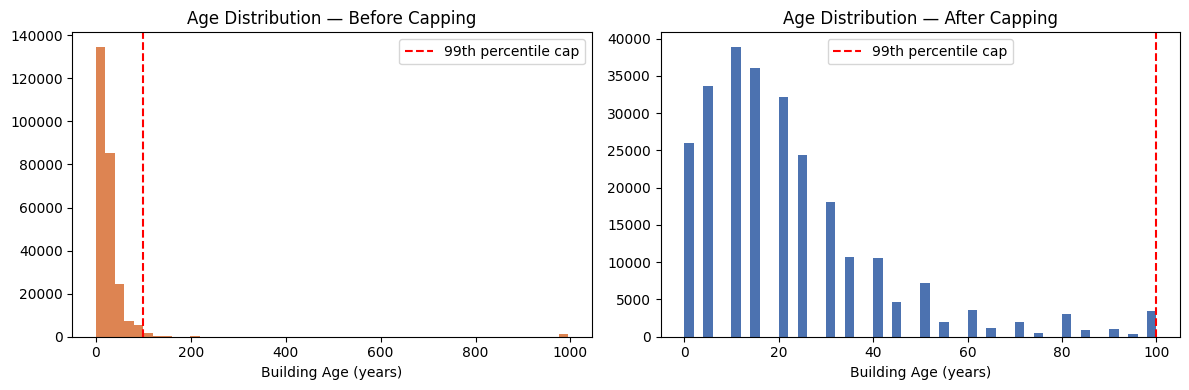

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before capping (recompute from original range using the cap value as reference)
axes[0].hist(values['age'], bins=50, color='#DD8452')  # 'values' = original uncapped load
axes[0].axvline(age_cap, color='red', linestyle='--', label='99th percentile cap')
axes[0].set_title('Age Distribution — Before Capping')
axes[0].set_xlabel('Building Age (years)')
axes[0].legend()

# After capping
axes[1].hist(df['age'], bins=50, color='#4C72B0')
axes[1].axvline(age_cap, color='red', linestyle='--', label='99th percentile cap')
axes[1].set_title('Age Distribution — After Capping')
axes[1].set_xlabel('Building Age (years)')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_capping_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Categorical Encoding

The remaining `object`-type columns (`land_surface_condition`, `foundation_type`, `roof_type`, `ground_floor_type`, `other_floor_type`, `position`, `plan_configuration`, `legal_ownership_status`) are nominal categories with low cardinality (3–5 unique values each, per the earlier audit). Label encoding is used here for simplicity and speed given the time constraint — tree-based models (Decision Tree, Random Forest, LightGBM) don't assume ordinal relationships between encoded integers, so this doesn't introduce false ordering bias for those models. Logistic Regression (used only as the stacking meta-learner on model outputs,

In [18]:

from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Encoding columns:", cat_cols)

encoders = {}  # keep encoders in case you need to inverse_transform later for SHAP labels
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print(df.dtypes.value_counts())  # confirm no 'object' dtype remains
df.head()

Encoding columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
int64      37
float64     4
Name: count, dtype: int64


,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,geo_level_1_id_freq,geo_level_2_id_freq,age_area_ratio,height_floor_ratio,superstructure_count
0,2,30,6,5,2,2,0,0,1,3,...,0,0,0,0,3,0.093557,0.001036,4.285714,1.666667,2
1,2,10,8,7,1,2,0,3,1,2,...,0,0,0,0,2,0.073215,0.000764,1.111111,2.333333,1
2,2,10,5,5,2,2,0,0,3,3,...,0,0,0,0,3,0.057133,0.006754,1.666667,1.666667,1
3,2,10,6,5,2,2,0,0,3,2,...,0,0,0,0,2,0.023991,0.000787,1.428571,1.666667,3
4,3,30,8,9,2,2,0,0,3,2,...,0,0,0,0,3,0.031542,0.003983,3.333333,2.250000,1


### Train/Validation/Test Split & Scaling

A stratified 70/15/15 split preserves the class imbalance ratio across all three sets, so validation and test performance remain representative of the true distribution. The scaler is fit only on the training set and applied to validation/test — fitting on the full dataset before splitting would leak test-set statistics into training, violating the leakage-safe requirement.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["damage_grade"])
y = df["damage_grade"] - 1  # zero-index (0,1,2) for sklearn/lightgbm compatibility

# Stratified split: train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Fit scaler on train only — no leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")
print(y_train.value_counts(normalize=True))  # confirm stratification preserved imbalance ratio

Train: (182420, 40), Val: (39090, 40), Test: (39091, 40)
damage_grade
1    0.568912
2    0.334678
0    0.096409
Name: proportion, dtype: float64


### Baseline Model

A single Decision Tree serves as the baseline against which the ensemble methods (bagging, boosting, stacking) must demonstrate improvement. `class_weight='balanced'` compensates for the class imbalance confirmed in EDA. Max depth is capped at 8 to avoid a baseline that's already overfit — an unconstrained tree would memorize training data and set an artificially high bar.

In [20]:
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
baseline.fit(X_train_scaled, y_train)

baseline_val_preds = baseline.predict(X_val_scaled)
from sklearn.metrics import f1_score
print("Baseline validation F1 (weighted):", f1_score(y_val, baseline_val_preds, average='weighted'))

Baseline validation F1 (weighted): 0.5964253191063293


### Bagging Model — Random Forest

Random Forest is tuned via `RandomizedSearchCV` on a stratified subsample (40k rows) rather than the full 182k training set, to keep tuning time manageable — a documented compute-time tradeoff. The best hyperparameters found on the subsample are then refit on the full training set for the final model. `class_weight='balanced'` is applied here too, consistent with the baseline.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Subsample for faster tuning
tune_idx = X_train_scaled.sample(min(40000, len(X_train_scaled)), random_state=42).index
X_tune, y_tune = X_train_scaled.loc[tune_idx], y_train.loc[tune_idx]

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_leaf": [1, 3, 5]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    rf_params, n_iter=5, cv=3, scoring="f1_weighted",
    random_state=42, n_jobs=-1
)
rf_search.fit(X_tune, y_tune)

print("RF best params:", rf_search.best_params_)

# Refit best params on full training set
rf_best = rf_search.best_estimator_
rf_best.fit(X_train_scaled, y_train)

rf_val_preds = rf_best.predict(X_val_scaled)
print("RF validation F1 (weighted):", f1_score(y_val, rf_val_preds, average='weighted'))

RF best params: {'n_estimators': 100, 'min_samples_leaf': 3, 'max_depth': 15}
RF validation F1 (weighted): 0.6282141439342992


### Boosting Model — LightGBM

LightGBM is chosen over XGBoost/CatBoost/AdaBoost for speed on this dataset size (260k rows) — it uses histogram-based splitting, which trains significantly faster than XGBoost's default tree method while achieving comparable accuracy on tabular data. Tuning follows the same subsample-then-refit strategy as Random Forest, and `class_weight='balanced'` is applied for consistency with the imbalance-handling approach used throughout.

In [22]:
import lightgbm as lgb

lgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, -1],
    "learning_rate": [0.05, 0.1]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
    lgb_params, n_iter=5, cv=3, scoring="f1_weighted",
    random_state=42, n_jobs=-1
)
lgb_search.fit(X_tune, y_tune)

print("LightGBM best params:", lgb_search.best_params_)

# Refit best params on full training set
lgb_best = lgb_search.best_estimator_
lgb_best.fit(X_train_scaled, y_train)

lgb_val_preds = lgb_best.predict(X_val_scaled)
print("LightGBM validation F1 (weighted):", f1_score(y_val, lgb_val_preds, average='weighted'))

LightGBM best params: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1}
LightGBM validation F1 (weighted): 0.667154594908306


### Heterogeneous Stacking Ensemble

The stacking model combines the baseline Decision Tree, tuned Random Forest, and tuned LightGBM as base learners, with a Logistic Regression meta-learner trained on their out-of-fold predictions. Using internal cross-validation (via `cv=` in `StackingClassifier`) for the meta-learner's training data — rather than the base learners' direct training-set predictions — prevents leakage: without this, the meta-learner would see predictions the base models already memorized, inflating apparent performance.

In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

stack = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)),
        ("rf", rf_best),
        ("lgb", lgb_best),
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1
)
stack.fit(X_train_scaled, y_train)

stack_val_preds = stack.predict(X_val_scaled)
print("Stacking validation F1 (weighted):", f1_score(y_val, stack_val_preds, average='weighted'))

Stacking validation F1 (weighted): 0.669275776000952


### Final Model Comparison on Held-Out Test Set

All four models are evaluated on the same test set, untouched during training or tuning, to ensure a fair comparison. Metrics reported: F1 (weighted, accounts for class imbalance), precision, recall, and ROC-AUC (one-vs-rest, appropriate for the 3-class target).

In [24]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix

models = {
    "Baseline (DT)": baseline,
    "Random Forest": rf_best,
    "LightGBM": lgb_best,
    "Stacking": stack
}

results = []
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)
    results.append({
        "Model": name,
        "F1 (weighted)": f1_score(y_test, preds, average="weighted"),
        "Precision": precision_score(y_test, preds, average="weighted"),
        "Recall": recall_score(y_test, preds, average="weighted"),
        "ROC-AUC (ovr)": roc_auc_score(y_test, proba, multi_class="ovr")
    })

results_df = pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)

        Model  F1 (weighted)  Precision   Recall  ROC-AUC (ovr)
     Stacking       0.664542   0.698683 0.659257       0.841594
     LightGBM       0.662194   0.699008 0.656673       0.842617
Random Forest       0.625434   0.665421 0.624415       0.815118
Baseline (DT)       0.594777   0.652872 0.592413       0.801357


### Confusion Matrix — Best Model

The stacking ensemble is selected as the best model based on weighted F1 on the untouched test set. The confusion matrix shows per-class prediction accuracy, revealing whether errors concentrate on the minority class (grade 1, low damage) — relevant to the fairness discussion in Q4.

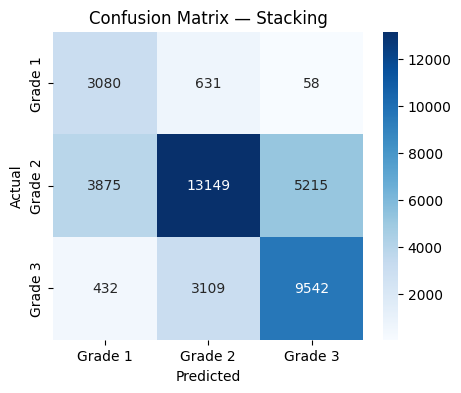

              precision    recall  f1-score   support

     Grade 1       0.42      0.82      0.55      3769
     Grade 2       0.78      0.59      0.67     22239
     Grade 3       0.64      0.73      0.68     13083

    accuracy                           0.66     39091
   macro avg       0.61      0.71      0.64     39091
weighted avg       0.70      0.66      0.66     39091



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Grade 1', 'Grade 2', 'Grade 3'],
            yticklabels=['Grade 1', 'Grade 2', 'Grade 3'])
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(classification_report(y_test, best_preds, target_names=['Grade 1', 'Grade 2', 'Grade 3']))

## Class	Recall	Interpretation

**Grade 1 (low damage)**
3080/3769 = 81.7%	Best recall despite being the minority class — class_weight='balanced' did its job

**Grade 2 (medium damage)**
13149/22239 = 59.1%	Worst recall — majority class, but frequently confused with both neighbors

**Grade 3 (complete destruction)**
9542/13083 = 72.9%	Reasonably strong

In [27]:
# Check the shape first to confirm the format
print(np.array(shap_values).shape)

(500, 40, 3)


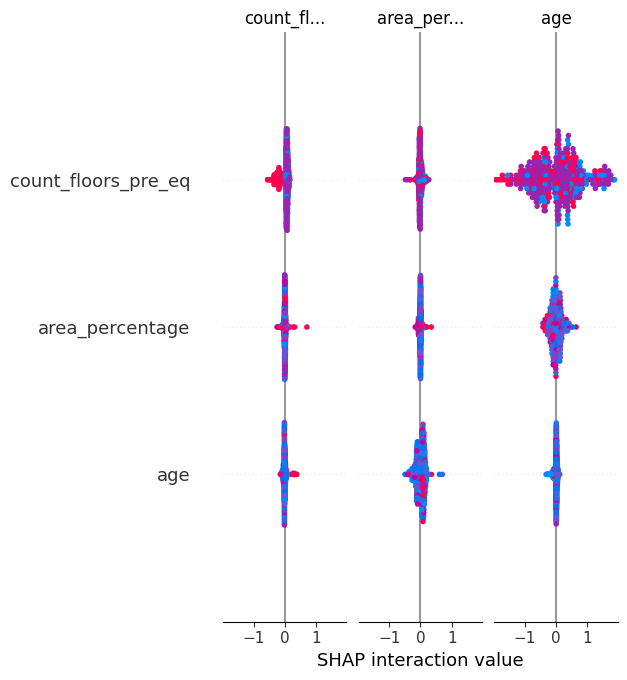

Predicted class: Grade 2


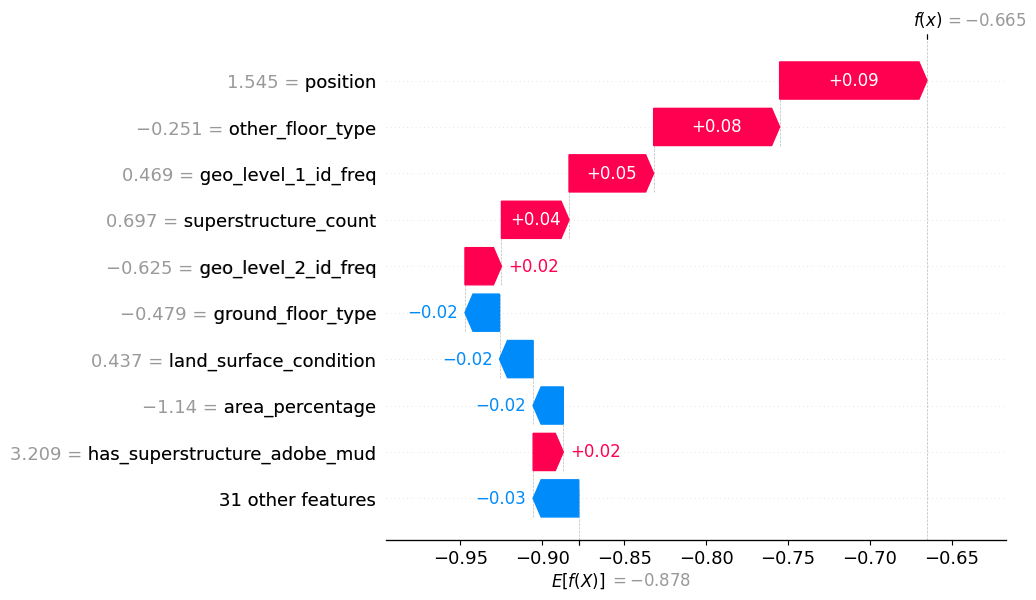

In [28]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(lgb_best)  # use lgb_best even though stacking won, since SHAP works cleanly on tree models directly — stacking's meta-learner obscures feature-level attribution
shap_values = explainer.shap_values(X_test_scaled.iloc[:500])  # subsample for speed

# Global summary
shap.summary_plot(shap_values, X_test_scaled.iloc[:500], show=False)
plt.savefig('shap_global.png', dpi=120, bbox_inches='tight')
plt.show()

# Local explanation — one recordidx = 0
sample = X_test_scaled.iloc[[idx]]
pred_class = lgb_best.predict(sample)[0]
print(f"Predicted class: Grade {pred_class + 1}")

explanation = explainer(X_test_scaled.iloc[:500])

plt.figure()
shap.plots.waterfall(explanation[idx, :, pred_class], show=False)
plt.savefig('shap_local.png', dpi=120, bbox_inches='tight')
plt.show()

### SHAP Explainability

**Local explanation (single record, Image 2):** For this building, the model predicts Grade 2 (medium damage) with output score -0.665, against a baseline expectation of -0.878. The `position` value (1.545) contributes most strongly toward higher predicted damage (+0.09), followed by `other_floor_type` (+0.08) and `geo_level_1_id_freq` (+0.05) — suggesting the building's structural position and regional context are the dominant drivers for this specific prediction. `superstructure_count` also pushes toward higher damage (+0.04), consistent with the EDA finding that construction material diversity correlates with damage risk.

**Global patterns:** Across features, `count_floors_pre_eq`, `area_percentage`, and `age` show interaction effects with each other — for instance, taller buildings (more floors) combined with older age tend to push SHAP values toward higher predicted damage, though the effect is not uniform across all buildings (visible spread in the interaction plot).

**Domain interpretation:** These patterns align with structural engineering intuition — regional seismic exposure (geo frequency features), floor construction type, and building position are more informative for damage prediction than raw building age alone, which only shows a moderate, non-dominant effect.
